
---

## 📚 Sobre este Material

Este material ha sido diseñado con el propósito de **capacitar, actualizar y practicar** conceptos fundamentales de Markdown en Jupyter Notebook. Es una herramienta pensada para facilitar el aprendizaje y la documentación efectiva de proyectos de análisis de datos y ciencia de datos.

### 🤝 Compartir y Colaborar

Este contenido es **libre para compartir, revisar, divulgar y mejorar**. Se promueve activamente su distribución en la comunidad para que más personas puedan beneficiarse y contribuir a su mejora continua. Tu feedback y sugerencias son siempre bienvenidos.

### 👨‍💻 Autor

**Andrés Muñoz**  
*AI & Data Strategy Leader passionate about NLP, LLMs, and MLOps. Driving innovation with data*

- 💼 LinkedIn: [in/amms1989](https://linkedin.com/in/amms1989)
- 🐙 GitHub: [https://github.com/anguihero](https://github.com/anguihero)

---

# Sesión 09: Métodos de Clasificación

**Autor:** anmmunozsa@outlook.es · Material de código abierto para compartir y aprender colectivamente.

## 🎯 Objetivo de la sesión
Construir y evaluar modelos de clasificación, entendiendo la matriz de confusión y cómo elegir la métrica correcta según el contexto de negocio.

## 🗺️ Tabla de Contenido
1. [Introducción: binaria vs. multiclase](#intro)
2. [El dataset: load_breast_cancer](#dataset)
3. [Regresión Logística](#logistica)
4. [K-Nearest Neighbors (KNN)](#knn)
5. [Support Vector Machine (SVM)](#svm)
6. [Árbol de Decisión](#arbol)
7. [Matriz de confusión y métricas](#metricas)
8. [Bonus: clasificación multiclase con load_wine](#multiclase)
9. [Ejemplos de aplicación real](#aplicaciones)
10. [Retos de práctica](#retos)


<a id="intro"></a>
## 1. Introducción (para dummies)

Un modelo de **clasificación** predice una **categoría**, no un número. Hay dos sabores:
- **Binaria:** solo 2 clases posibles (maligno/benigno, spam/no spam).
- **Multiclase:** 3 o más clases (tipo de vino, especie de planta).

Hoy usaremos `load_breast_cancer` (diagnóstico de cáncer de mama: maligno vs. benigno) para el grueso de la sesión, y cerraremos con un vistazo rápido a `load_wine` (3 clases) para ver que los mismos algoritmos se extienden naturalmente al caso multiclase.

<a id="dataset"></a>
## 2. El Dataset: load_breast_cancer

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:

# descaragamos datos
datos = load_breast_cancer(as_frame=True)
df = datos.frame
print("Clases:", dict(enumerate(datos.target_names)))
print("Balance de clases:\n", df["target"].value_counts())

# separamos las variables/columnas en las X (caracteristicas) y la y  (caracteristica objetivo)
X = df.drop(columns=["target"])
y = df["target"]

# particionar / partir los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
    stratify=y # selecciono la caracteristica que tiene el balance que se quiere mantener para garanatizar representatividad est6ratos)
)
# mistrar resultado de la particion
print(X_train.shape, X_test.shape)

Clases: {0: np.str_('malignant'), 1: np.str_('benign')}
Balance de clases:
 target
1    357
0    212
Name: count, dtype: int64
(455, 30) (114, 30)


> 💡 `stratify=y` asegura que la proporción de clases (maligno/benigno) sea similar en entrenamiento y prueba — importante cuando hay algo de desbalance.

<a id="logistica"></a>
## 3. Regresión Logística

### 🔬 Teoría técnica
A pesar del nombre, es un modelo de **clasificación**. Usa la función sigmoide para convertir cualquier valor en una probabilidad entre 0 y 1:

$$P(y=1) = \frac{1}{1 + e^{-z}}$$

**Hiperparámetros clave:** `C` (inverso de la fuerza de regularización — valores pequeños = más regularización), `penalty` (L1/L2), `solver`.

In [3]:
# importo las funciones/ nclases/metodos que quiero usar
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [5]:
# preparar datos :
# escalación estandar (estima el promedio de cada variable y la desviación estandar y centra los datos en cero)
# motivo : KNN, SVM y Logística son sensibles a la escala -> estandarizamos

escalador = StandardScaler() # 1. Iniciar el modelo de escalamiento
X_train_esc = escalador.fit_transform(X_train) # 2. ajusto a datos de entrenamiento y 3. transformo los datos (prueba)
X_test_esc = escalador.transform(X_test) # 3. transformo datos (prueba)


In [6]:

# ajustar el modelo de reg logistica
log_reg = LogisticRegression(C=1.0, max_iter=5000) # 1. inicio el modelo / 1.a parametrizandolo
log_reg.fit(X_train_esc, y_train) # 2. ajusto a los datos de entrenamiento
print("Accuracy en prueba:", log_reg.score(X_test_esc, y_test)) # 3. valido desemepño en datos de prueba

Accuracy en prueba: 0.9824561403508771


### 🧠 Resumen para dummies
Úsala cuando necesites **probabilidades interpretables** y un modelo rápido como línea base.

<a id="knn"></a>
## 4. K-Nearest Neighbors (KNN)

### 🔬 Teoría técnica
Clasifica un punto nuevo según la clase mayoritaria de sus `K` vecinos más cercanos. **Hiperparámetros clave:** `n_neighbors` (K), `weights` (uniform/distance), `metric` (euclidean, manhattan). Es muy sensible a la escala de las variables (por eso estandarizamos antes).

In [7]:
from sklearn.neighbors import KNeighborsClassifier # 0. importar el modelo

knn = KNeighborsClassifier( # 1. iniciar el modelo 1.a parametrizandolo
    n_neighbors=5,
    weights = 'uniform' # {‘uniform’, ‘distance’},
    )
knn.fit(X_train_esc, y_train) # 2. ajustar el modelo a datos de entrenamiento
print("Accuracy en prueba:", knn.score(X_test_esc, y_test)) # 3. validar el ajuste con metricas sobre los datos de prueba

Accuracy en prueba: 0.956140350877193


### 🧠 Resumen para dummies
"Dime con quién andas y te diré quién eres": KNN mira a los vecinos más parecidos y copia su clase mayoritaria.

<a id="svm"></a>
## 5. Support Vector Machine (SVM)

### 🔬 Teoría técnica
Busca el hiperplano que separa las clases **maximizando el margen** entre ellas. **Hiperparámetros clave:** `C` (penalización de errores), `kernel` (`linear`, `rbf`), `gamma` (influencia de cada punto en el kernel `rbf`).

In [8]:
from sklearn.svm import SVC # 0.  importamos

svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True) # 1. iniciamos
svm.fit(X_train_esc, y_train) # 2. ajustamosa datos de entrenamiento
print("Accuracy en prueba:", svm.score(X_test_esc, y_test)) # 3. validamos en datos de prueba

Accuracy en prueba: 0.9824561403508771


### 🧠 Resumen para dummies
SVM traza la "frontera más segura" posible entre las clases; con `kernel="rbf"` puede separar formas que no son una línea recta.

<a id="arbol"></a>
## 6. Árbol de Decisión

### 🔬 Teoría técnica
Divide el dataset en subconjuntos haciendo preguntas tipo "¿la variable X es mayor a Z?", formando una estructura de árbol. **Hiperparámetros clave:** `max_depth`, `min_samples_split`, `criterion` (gini/entropy). No requiere escalado.

In [13]:
from sklearn.tree import DecisionTreeClassifier # 0. importar la clase del modelo

arbol = DecisionTreeClassifier( # 1. iniciar el modelo
    max_depth=4, # cantidad de cortes
    min_samples_split = 8, # minima cantidad de datos que debe tener para poder realizar un corte
    min_samples_leaf = 4, # minima cantidad de datos que debe tener una hoja final
    random_state=42
    )
arbol.fit(X_train, y_train)  # los árboles no necesitan escalado. # 2. ajuste a datos de entrenamiento
print("Accuracy en prueba:", arbol.score(X_test, y_test)) # 3.  valide en datos de prueba

Accuracy en prueba: 0.9210526315789473


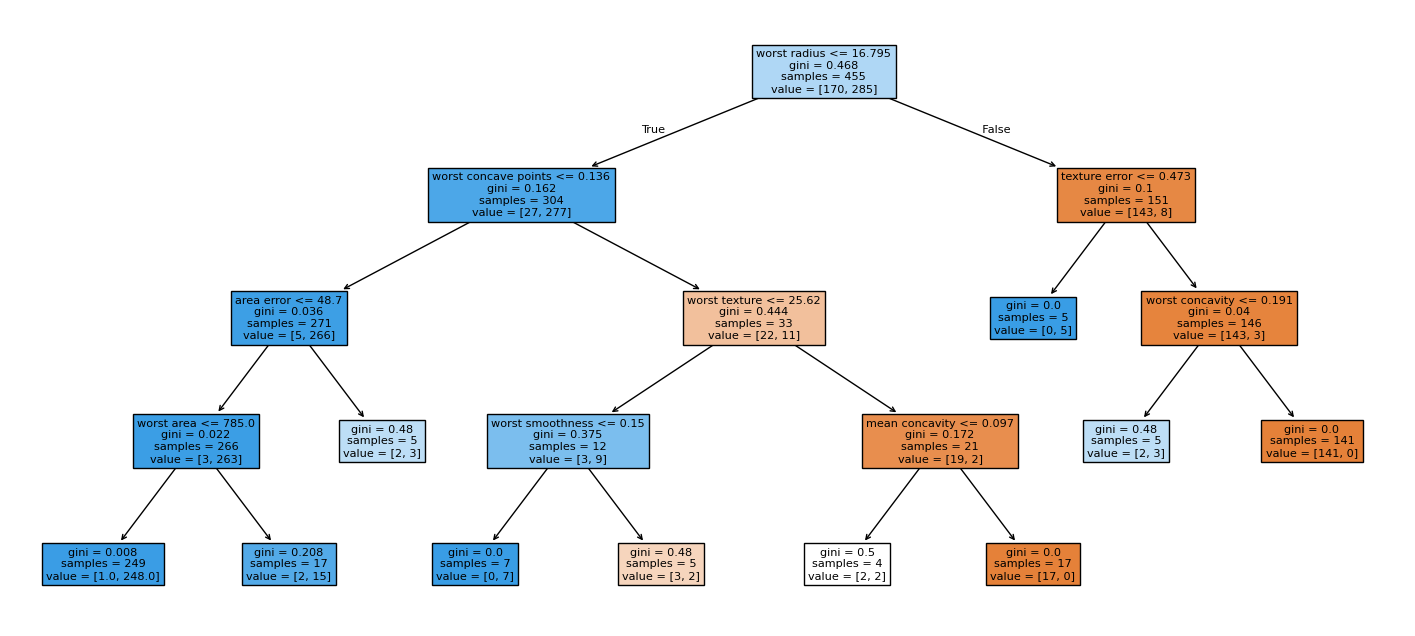

In [15]:

import matplotlib.pyplot as plt # viz
import seaborn as sns # viz
from sklearn.tree import plot_tree

# Graficar el árbol
plt.figure(figsize=(18, 8))
plot_tree(arbol, feature_names=datos.feature_names, filled=True)
plt.show()

### 💪 Fortalezas y debilidades (resumen de los 4 métodos)

| Algoritmo | Fortaleza | Debilidad |
|---|---|---|
| Regresión Logística | Interpretable, probabilidades calibradas | Solo fronteras lineales |
| KNN | Simple, sin asumir distribución | Lento en predicción, sensible a escala |
| SVM | Efectivo en alta dimensión | Difícil de interpretar, lento con datasets grandes |
| Árbol de Decisión | Muy interpretable, sin escalado | Propenso a overfitting si no se limita la profundidad |

<a id="metricas"></a>
## 7. Matriz de Confusión y Métricas

### 🔬 Teoría técnica
| | Predicho Positivo | Predicho Negativo |
|---|---|---|
| **Real Positivo** | TP | FN |
| **Real Negativo** | FP | TN |

- **Accuracy** = (TP+TN) / Total
- **Precision** = TP / (TP+FP) — de lo que dije "positivo", ¿cuánto acerté?
- **Recall** = TP / (TP+FN) — de los positivos reales, ¿cuántos detecté?
- **F1** = media armónica de Precision y Recall
- **AUC-ROC** = capacidad de discriminar entre clases a distintos umbrales

> 📌 En diagnóstico médico (este dataset), un **Falso Negativo** (decir "benigno" cuando es maligno) es el error más grave → se prioriza **Recall**.

In [16]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

modelos = {"Logística": log_reg, "KNN": knn, "SVM": svm, "Árbol": arbol}

for nombre, modelo in modelos.items():
    X_eval = X_test if nombre == "Árbol" else X_test_esc
    pred = modelo.predict(X_eval)
    print(f"--- {nombre} ---")
    print(classification_report(y_test, pred, target_names=datos.target_names))

--- Logística ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

--- KNN ---
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

--- SVM ---
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.9

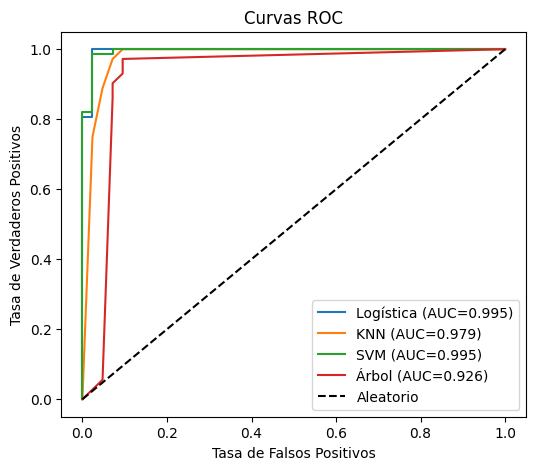

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
for nombre, modelo in modelos.items():
    X_eval = X_test if nombre == "Árbol" else X_test_esc
    proba = modelo.predict_proba(X_eval)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Curvas ROC")
ax.legend()
plt.show()

### 🧠 Resumen para dummies
Un AUC de 1.0 es perfecto, 0.5 es "adivinar al azar". Mira siempre el `classification_report` completo, no solo el accuracy — un modelo puede tener 95% de accuracy y aun así fallar en detectar la mayoría de los casos malignos si las clases están desbalanceadas.

<a id="multiclase"></a>
## 8. Bonus: Clasificación Multiclase con load_wine

### 🔬 Teoría técnica
Los mismos algoritmos se extienden a más de 2 clases casi sin cambios — scikit-learn maneja la estrategia "uno contra todos" (o similar) automáticamente.

In [ ]:
from sklearn.datasets import load_wine

vino = load_wine(as_frame=True)
df_vino = vino.frame
print("Clases:", dict(enumerate(vino.target_names)))

Xv = df_vino.drop(columns=["target"])
yv = df_vino["target"]
Xv_train, Xv_test, yv_train, yv_test = train_test_split(Xv, yv, test_size=0.2, random_state=42, stratify=yv)

log_reg_multi = LogisticRegression(max_iter=5000)
log_reg_multi.fit(Xv_train, yv_train)

print("Accuracy multiclase:", log_reg_multi.score(Xv_test, yv_test))
print(classification_report(yv_test, log_reg_multi.predict(Xv_test), target_names=vino.target_names))

### 🧠 Resumen para dummies
En multiclase, el `classification_report` te da precision/recall/F1 **por cada clase** — revísalas todas, no solo el promedio general.

## 🔎 Laboratorio de profundización: probabilidad, log-loss y umbral

Regresión logística transforma un puntaje lineal mediante la sigmoide:

$$p(y=1|x)=\sigma(z)=\frac{1}{1+e^{-z}},\qquad z=w^Tx+b$$

Minimiza entropía cruzada binaria:

$$L=-\frac{1}{n}\sum[y\log(p)+(1-y)\log(1-p)]$$

El optimizador actualiza los coeficientes en dirección opuesta al gradiente. La clase final depende además de un **umbral**, normalmente 0.5; cambiarlo modifica precision y recall.


In [ ]:
# Paso 1: inspeccionar probabilidades, no solo clases
modelo_logistico = LogisticRegression(max_iter=2000, random_state=42)
modelo_logistico.fit(X_train_esc, y_train)
prob_pos = modelo_logistico.predict_proba(X_test_esc)[:, 1]
print(prob_pos[:5])
print(modelo_logistico.get_params()["C"])


In [ ]:
# Paso 2: cambiar el umbral de decisión
from sklearn.metrics import precision_score, recall_score

for umbral in [0.30, 0.50, 0.70]:
    pred_umbral = (prob_pos >= umbral).astype(int)
    print(umbral, {
        "precision": round(precision_score(y_test, pred_umbral), 3),
        "recall": round(recall_score(y_test, pred_umbral), 3),
    })


### Hiperparámetros por método

- Logística: `C` es el inverso de regularización; `penalty`, `solver`, `max_iter`.
- KNN: `n_neighbors`, `weights`, `metric`; requiere escala.
- SVM: `C`, `kernel`, `gamma`; `probability=True` añade costo.
- Árbol: `max_depth`, `min_samples_split`, `min_samples_leaf`, `criterion`.

Usa `.get_params()` para inspeccionar configuración y atributos terminados en `_` (`coef_`, `classes_`, `tree_`) para revisar lo aprendido.


<a id="aplicaciones"></a>
## 9. Ejemplos de Aplicación en el Mundo Real

- Diagnóstico médico automatizado (el caso de hoy).
- Detección de fraude en transacciones (binaria, muy desbalanceada).
- Clasificación de tipos de producto o especies (multiclase).

<a id="retos"></a>
## 10. Retos de Práctica

### 🥉 Reto Básico
Entrena una Regresión Logística sobre `load_breast_cancer` y reporta accuracy, precision, recall y F1 con `classification_report`.

In [ ]:
# Tu solución al Reto Básico aquí


### 🥈 Reto Medio
Entrena KNN probando 3 valores distintos de `n_neighbors` (ej. 3, 5, 11) y compara sus matrices de confusión. ¿Cuál da mejor Recall para la clase "maligno"?

In [ ]:
# Tu solución al Reto Medio aquí


### 🥇 Reto Avanzado
Sobre `load_wine`, entrena los 4 algoritmos (Logística, KNN, SVM, Árbol) y compara su accuracy multiclase en una tabla. Adicionalmente, identifica con una matriz de confusión (`confusion_matrix` de 3x3) cuál par de clases se confunde más entre sí.

In [ ]:
# Tu solución al Reto Avanzado aquí
